In [1]:
import time
from sympleq.models.random_hamiltonian import random_gate_symmetric_hamiltonian
from sympleq.core.circuits import SWAP
from sympleq.core.symmetries.clifford import find_clifford_symmetries, qudit_cost, min_qudit_clifford_symmetry
from sympleq.core.circuits import Circuit
import numpy as np

In [ ]:
n_tests = 50
p = 2
n_qudits_list = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]  # 

times = []

for n_qudits in n_qudits_list:
    t_each_run = []
    n_paulis = n_qudits * 3 + 10
        
    for _ in range(n_tests):
        
        sym = SWAP(0, 1, p)
        # unscrambled H
        H = random_gate_symmetric_hamiltonian(sym, n_qudits, n_paulis, scrambled=False)
        C = Circuit.from_random(1000, H.dimensions).composite_gate()  # scrambling circuit
        H = C.act(H)
        H.weight_to_phase()
        scrambled_sym = Circuit(H.dimensions, [C.inv(), sym, C]).composite_gate()
        assert H.to_standard_form() == scrambled_sym.act(H).to_standard_form(
        ), f"\n{H.to_standard_form().__str__()}\n{sym.act(H).to_standard_form().__str__()}"

        known_F = scrambled_sym.symplectic

        start = time.time()
        symmetries = find_clifford_symmetries(H)

        assert len(symmetries) != 0

        for c in symmetries:
            # print(np.all(c.symplectic == known_F) and np.all(
            #     c.phase_vector == scrambled_sym.phase_vector))
            H_s = H.to_standard_form()
            H_out = c.act(H).to_standard_form()
            H_s.weight_to_phase()
            H_out.weight_to_phase()
            assert np.all(H_s.tableau == H_out.tableau)
            assert np.all(H_s.phases == H_out.phases)
            assert np.all(H_s.weights == H_out.weights)
            assert c.act(H).to_standard_form() == H.to_standard_form()
        print('done n_qudits=', n_qudits, ' run number ', _, 'time=', time.time() - start)
        end = time.time()
        t_each_run.append(end - start)
    times.append(t_each_run)

mean_times = [np.mean(t) for t in times]
median_times = [np.median(t) for t in times]
times_max = [np.max(t) for t in times]
times_min = [np.min(t) for t in times]
variances = [np.var(t) for t in times]

done n_qudits= 10  run number  0 time= 2.269137144088745
done n_qudits= 10  run number  1 time= 1.375645637512207
done n_qudits= 10  run number  2 time= 1.436985969543457
done n_qudits= 10  run number  3 time= 1.2911372184753418
done n_qudits= 10  run number  4 time= 1.327437162399292
done n_qudits= 10  run number  5 time= 1.5002379417419434
done n_qudits= 10  run number  6 time= 1.4577291011810303
done n_qudits= 10  run number  7 time= 1.30694580078125
done n_qudits= 10  run number  8 time= 1.3116040229797363
done n_qudits= 10  run number  9 time= 1.402005910873413
done n_qudits= 10  run number  10 time= 1.4979126453399658
done n_qudits= 10  run number  11 time= 1.4452910423278809
done n_qudits= 10  run number  12 time= 1.5302214622497559
done n_qudits= 10  run number  13 time= 1.434175729751587
done n_qudits= 10  run number  14 time= 1.3530337810516357
done n_qudits= 10  run number  15 time= 1.3885204792022705
done n_qudits= 10  run number  16 time= 1.266629695892334
done n_qudits= 1

Text(0, 0.5, 'Time to find SWAP symmetry (s)')

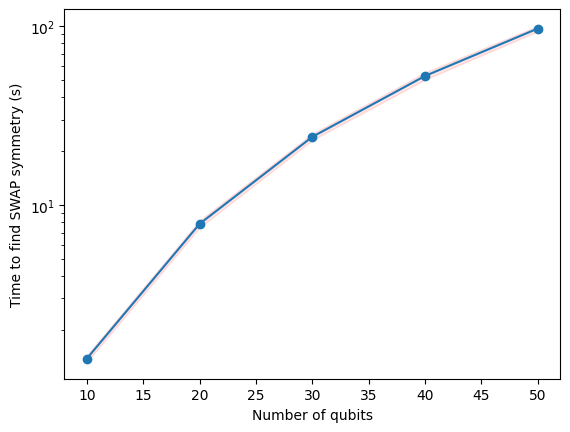

In [13]:
# plot times and variances
import matplotlib.pyplot as plt
plt.semilogy(n_qudits_list, mean_times, marker='o')
# plt.semilogy(n_qudits_list, median_times, marker='x', label='Median')
# fill in area between max and min
# plt.fill_between(n_qudits_list, times_max, times_min, alpha=0.2)
# standard deviation of each n_q
std_dev = np.asarray([np.std(times[i]) for i in range(len(n_qudits_list))])
plt.fill_between(n_qudits_list, mean_times - std_dev, mean_times + std_dev, alpha=0.1, color='red', label='Std Dev')
# plt.legend()
# plt.plot(n_qs, times_max, marker='^', label='Max')
# plt.plot(n_qs, times_min, marker='d', label='Min')
plt.xlabel('Number of qubits')
plt.ylabel('Time to find SWAP symmetry (s)')